# 8-1절 연습 문제 풀이

이 노트북은 8-1절 연습 문제(8-1 ~ 8-3)의 풀이 예시다.

- 본문 예제 코드는 `code_examples/ch08/08-01_example.ipynb`를 참고한다.
- 학습 환경과 데이터로더는 본문 예제와 같게 맞춰 결과를 그대로 견줄 수 있게 했다.
- 문제마다 **풀이 해설**과 **문제 검토**를 함께 실었다. 문제 검토는 최종 검토 3단계의 기록이다.

## 공통 준비 — 환경 설정, 데이터로더, 기준 모델, 학습 함수

In [1]:
# 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

SEED = 42
common.set_seed(SEED, deterministic=True)
device = common.get_device()

CUDA를 사용합니다.


In [2]:
# CIFAR-10 데이터로더 (본문 예제 08-01_example.ipynb와 동일)
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

data_root = '../../download'

CIFAR_MEAN = (0.5, 0.5, 0.5)
CIFAR_STD = (0.5, 0.5, 0.5)

# 검증, 평가 데이터셋 데이터 변환 객체 (증강 없음)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 훈련 데이터셋 데이터 변환 객체 (증강 추가)
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

TRAIN_SIZE, VALID_SIZE = 40000, 10000
BATCH_SIZE = 64

full_train_set = datasets.CIFAR10(root=data_root, train=True,
                                  download=True, transform=train_transform)
full_eval_set = datasets.CIFAR10(root=data_root, train=True,
                                 download=True, transform=transform)
test_set = datasets.CIFAR10(root=data_root, train=False,
                            download=True, transform=transform)

common.set_seed(SEED, deterministic=True)
train_set, valid_set = random_split(full_train_set, [TRAIN_SIZE, VALID_SIZE])
common.set_seed(SEED, deterministic=True)
train_evaluate_set, _ = random_split(full_eval_set, [TRAIN_SIZE, VALID_SIZE])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
train_evaluate_loader = DataLoader(train_evaluate_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련 {len(train_set)}, 검증 {len(valid_set)}, 평가 {len(test_set)}')

훈련 40000, 검증 10000, 평가 10000


In [3]:
# 기준 모델 MiniVGGNet ([코드 8-1]과 같음)
import torch.nn as nn


class MiniVGGNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        def vgg_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        self.features = nn.Sequential(
            vgg_block(3, 32),               # (B, 3, 32, 32) -> (B, 32, 16, 16)
            vgg_block(32, 64),              #                -> (B, 64, 8, 8)
            vgg_block(64, 128)              #                -> (B, 128, 4, 4)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (B, 128, 4, 4) -> (B, 128 * 4 * 4)
            nn.Linear(128 * 4 * 4, 128),    #                -> (B, 128)
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, num_classes)     #                -> (B, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [4]:
# 학습에 사용하는 함수 (본문 예제와 동일)
import copy

import torch.optim as optim


def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (outputs.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size


def train_with_early_stopping(model, train_loader, valid_loader,
                              criterion, optimizer, epochs, patience,
                              device):
    model.to(device)
    log = common.EpochLogger(epochs, target_rows=epochs)
    best_valid_loss = float('inf')
    best_epoch = -1
    best_model_params = None
    patience_counter = 0
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)
        log.row(epoch, train_loss, valid_loss, valid_acc * 100)
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
            best_model_params = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    if best_model_params is not None:
        print(f'최적 에포크({best_epoch}, 최소 검증 손실 {best_valid_loss:.4f})의 파라미터로 복원')
        model.load_state_dict(best_model_params)
    return log, best_epoch


def run_training(model_class, name, epochs=200, patience=10, lr=1e-3):
    """모델 클래스를 받아 학습하고 훈련/평가 결과를 요약해 반환한다."""
    common.set_seed(SEED, deterministic=True)
    model = model_class()
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    print(f'{name} 학습')
    log, best_epoch = train_with_early_stopping(
        model, train_loader, valid_loader, criterion, optimizer,
        epochs, patience, device
    )
    train_loss, train_acc = evaluate(model, train_evaluate_loader, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    result = {
        'name': name,
        'best_epoch': best_epoch,
        'train_loss': train_loss, 'test_loss': test_loss,
        'train_acc': train_acc * 100, 'test_acc': test_acc * 100,
        'params': common.count_params(model),
    }
    print(f"{name}: 최적 에포크 {best_epoch}, "
          f"훈련 손실 {train_loss:.4f} / 평가 손실 {test_loss:.4f}, "
          f"훈련 정확도 {train_acc * 100:.2f}% / 평가 정확도 {test_acc * 100:.2f}%")
    return model, result


EPOCHS = 200
PATIENCE = 10
LR = 1e-3
results = {}

---

## 연습 문제 8-1

> `MiniVGGNet` 모델은 합성곱 계층이 출력하는 데이터의 채널 수를 32, 64, 128로 두 배씩 늘려 가며
> 특징을 추출한다. 이 모델의 모든 합성곱 계층의 출력 채널 수를 64로 고정한 후, 다음 관점으로 결과를
> 확인해 보자.
> - 전체 파라미터 수와 메모리 사용량의 변화
> - 모델의 성능

In [5]:
# 모든 합성곱 계층의 출력 채널 수를 64로 고정한 모델
class MiniVGGNet64(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        def vgg_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        # 세 블록 모두 출력 채널 수를 64로 고정
        self.features = nn.Sequential(
            vgg_block(3, 64),               # (B, 3, 32, 32) -> (B, 64, 16, 16)
            vgg_block(64, 64),              #                -> (B, 64, 8, 8)
            vgg_block(64, 64)               #                -> (B, 64, 4, 4)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (B, 64, 4, 4)  -> (B, 64 * 4 * 4)
            nn.Linear(64 * 4 * 4, 128),     #                -> (B, 128)
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, num_classes)     #                -> (B, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [6]:
# 파라미터 수와 메모리 사용량 비교
from torchinfo import summary

info_base = summary(MiniVGGNet(), input_size=(64, 3, 32, 32),
                    device='cpu', verbose=0)
info_64 = summary(MiniVGGNet64(), input_size=(64, 3, 32, 32),
                  device='cpu', verbose=0)

# torchinfo가 요약 정보에 쓰는 것과 같은 단위(10^6바이트)를 사용해
# [표 8-1]의 값과 바로 견줄 수 있게 한다
MB = 10 ** 6
rows = [
    ('파라미터 수(개)',
     f'{info_base.total_params:,}', f'{info_64.total_params:,}'),
    ('파라미터 메모리(MB)',
     f'{info_base.total_param_bytes / MB:.2f}', f'{info_64.total_param_bytes / MB:.2f}'),
    ('순전파/역전파 메모리(MB)',
     f'{info_base.total_output_bytes / MB:.2f}', f'{info_64.total_output_bytes / MB:.2f}'),
    ('전체 메모리(MB)',
     f'{(info_base.total_input + info_base.total_output_bytes + info_base.total_param_bytes) / MB:.2f}',
     f'{(info_64.total_input + info_64.total_output_bytes + info_64.total_param_bytes) / MB:.2f}'),
    ('연산량(mult-adds, G)',
     f'{info_base.total_mult_adds / 1e9:.2f}', f'{info_64.total_mult_adds / 1e9:.2f}'),
]
print(f"{'항목':<26}{'MiniVGGNet':>14}{'MiniVGGNet64':>16}")
print('-' * 56)
for label, a, b in rows:
    print(f'{label:<26}{a:>14}{b:>16}')

항목                            MiniVGGNet    MiniVGGNet64
--------------------------------------------------------
파라미터 수(개)                        550,570         318,922
파라미터 메모리(MB)                        2.20            1.28
순전파/역전파 메모리(MB)                    58.79           88.15
전체 메모리(MB)                         61.78           90.21
연산량(mult-adds, G)                   2.50            4.06


In [7]:
# 두 모델 학습 및 평가
model_base, results['MiniVGGNet'] = run_training(MiniVGGNet, 'MiniVGGNet', EPOCHS, PATIENCE, LR)

MiniVGGNet 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.8597       1.5031       43.41%     0:14


  2/200       1.4764       1.2234       54.71%     0:28


  3/200       1.2820       1.1060       59.95%     0:42


  4/200       1.1634       1.0479       62.00%     0:56


...

 49/200       0.4094       0.5575       82.60%    13:26


 50/200       0.4097       0.5490       82.81%    13:44


 51/200       0.4128       0.5801       81.95%    14:03


 52/200       0.4023       0.5544       82.74%    14:22
최적 에포크(42, 최소 검증 손실 0.5410)의 파라미터로 복원


MiniVGGNet: 최적 에포크 42, 훈련 손실 0.3274 / 평가 손실 0.5511, 훈련 정확도 88.50% / 평가 정확도 83.02%


In [8]:
model_64, results['MiniVGGNet64'] = run_training(MiniVGGNet64, 'MiniVGGNet64', EPOCHS, PATIENCE, LR)

MiniVGGNet64 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.8490       1.6054       39.41%     0:20


  2/200       1.4810       1.2744       53.68%     0:39


  3/200       1.2600       1.1221       59.08%     0:59


  4/200       1.1215       1.0405       63.05%     1:18


...

 65/200       0.3951       0.5473       82.98%    19:49


 66/200       0.3997       0.5320       83.21%    20:08


 67/200       0.4003       0.5566       82.69%    20:27


 68/200       0.4022       0.5800       82.11%    20:46
최적 에포크(58, 최소 검증 손실 0.5146)의 파라미터로 복원


MiniVGGNet64: 최적 에포크 58, 훈련 손실 0.3043 / 평가 손실 0.5248, 훈련 정확도 89.23% / 평가 정확도 83.35%


In [9]:
# 결과 정리
def print_results(keys):
    print(f"{'모델':<18}{'최적 에포크':>10}{'훈련 손실':>10}{'평가 손실':>10}"
          f"{'훈련 정확도':>12}{'평가 정확도':>12}{'파라미터':>12}")
    print('-' * 84)
    for k in keys:
        r = results[k]
        print(f"{r['name']:<18}{r['best_epoch']:>10}{r['train_loss']:>10.4f}"
              f"{r['test_loss']:>10.4f}{r['train_acc']:>11.2f}%{r['test_acc']:>11.2f}%"
              f"{r['params']:>12,}")


print_results(['MiniVGGNet', 'MiniVGGNet64'])

모델                    최적 에포크     훈련 손실     평가 손실      훈련 정확도      평가 정확도        파라미터
------------------------------------------------------------------------------------
MiniVGGNet                42    0.3274    0.5511      88.50%      83.02%     550,570
MiniVGGNet64              58    0.3043    0.5248      89.23%      83.35%     318,922


### 풀이 해설 — 연습 문제 8-1

**파라미터 수는 오히려 줄어든다.** 채널 수를 64로 "고정"한다는 말이 언뜻 모델을 키우는 것처럼
들리지만, 실제로는 마지막 블록의 채널이 128에서 64로 **줄어든다**. 합성곱 계층의 파라미터 수는
`입력 채널 x 출력 채널 x 필터 크기`에 비례하므로 뒤쪽 블록일수록 파라미터가 무겁고, 그 무거운
쪽을 절반으로 깎은 효과가 앞쪽 블록이 커진 효과보다 크다. 분류기의 입력도 `128 * 4 * 4`에서
`64 * 4 * 4`로 절반이 되어 선형 계층의 파라미터도 함께 줄어든다.

**메모리는 반대로 늘어난다.** 특징 지도가 차지하는 메모리는 `채널 수 x 가로 x 세로`에 비례하는데,
해상도가 가장 큰 앞쪽 블록의 채널이 32에서 64로 두 배가 되기 때문이다. 32x32 해상도에서 채널이
두 배가 되는 비용은 4x4 해상도에서 채널이 절반이 되는 이득보다 훨씬 크다. 연산량도 같은 이유로
늘어난다.

**즉 이 문제의 핵심은 "파라미터 수와 메모리 사용량이 서로 반대 방향으로 움직인다"는 것이다.**
5장부터 파라미터 수로 모델의 크기를 가늠해 온 독자에게, 파라미터가 줄었는데 메모리와 연산량은
늘어나는 상황을 보여 준다. 8-1절이 `torchinfo.summary()`의 메모리 요약 정보를 굳이 설명한 이유를
여기서 확인할 수 있다.

성능 비교는 위 표의 실행 결과로 확인한다.

---

## 연습 문제 8-2

> VGGNet이 입증한 것처럼 모델의 깊이를 늘릴수록 모델 성능이 좋아지는지 `MiniVGGNet` 모델을
> 다음 두 가지 방향으로 각각 수정해 직접 확인해 보자.
> - VGG 블록에 합성곱 계층과 ReLU 활성화 계층 한 쌍을 더 추가한 모델
> - 특징 추출기 계층(`features`)에 VGG 블록을 하나 더 추가한 모델
>
> 계층을 추가했음에도 불구하고 모델의 성능이 좋아지지 않았다면 그 이유가 무엇일지 추측해 보자.

In [10]:
# (1) VGG 블록마다 합성곱 + ReLU 한 쌍을 더 추가한 모델 (합성곱 계층 6개 -> 9개)
class MiniVGGNetDeepBlock(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        def vgg_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                # 추가한 합성곱 계층과 활성화 계층 한 쌍
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        self.features = nn.Sequential(
            vgg_block(3, 32),               # (B, 3, 32, 32) -> (B, 32, 16, 16)
            vgg_block(32, 64),              #                -> (B, 64, 8, 8)
            vgg_block(64, 128)              #                -> (B, 128, 4, 4)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# (2) 특징 추출기에 VGG 블록을 하나 더 추가한 모델 (합성곱 계층 6개 -> 8개)
class MiniVGGNetExtraBlock(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        def vgg_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        self.features = nn.Sequential(
            vgg_block(3, 32),               # (B, 3, 32, 32) -> (B, 32, 16, 16)
            vgg_block(32, 64),              #                -> (B, 64, 8, 8)
            vgg_block(64, 128),             #                -> (B, 128, 4, 4)
            vgg_block(128, 256)             #                -> (B, 256, 2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (B, 256, 2, 2) -> (B, 256 * 2 * 2)
            nn.Linear(256 * 2 * 2, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
model_deep, results['DeepBlock'] = run_training(
    MiniVGGNetDeepBlock, 'MiniVGGNetDeepBlock', EPOCHS, PATIENCE, LR)

MiniVGGNetDeepBlock 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.9878       1.7500       34.20%     0:19


  2/200       1.6978       1.5114       42.44%     0:39


  3/200       1.5058       1.3105       51.62%     0:58


  4/200       1.3484       1.2807       53.38%     1:17


...

 55/200       0.4841       0.5788       81.49%    14:48


 56/200       0.4791       0.5999       80.46%    15:03


 57/200       0.4781       0.5826       81.23%    15:17


 58/200       0.4799       0.5952       81.02%    15:31
최적 에포크(48, 최소 검증 손실 0.5758)의 파라미터로 복원


MiniVGGNetDeepBlock: 최적 에포크 48, 훈련 손실 0.4144 / 평가 손실 0.5783, 훈련 정확도 85.56% / 평가 정확도 80.96%


In [12]:
model_extra, results['ExtraBlock'] = run_training(
    MiniVGGNetExtraBlock, 'MiniVGGNetExtraBlock', EPOCHS, PATIENCE, LR)

MiniVGGNetExtraBlock 학습


 에포크    훈련 손실    검증 손실    정확도(%)     시간
  1/200       1.9610       1.7795       29.39%     0:15


  2/200       1.6784       1.5087       42.45%     0:29


  3/200       1.4696       1.3187       51.15%     0:43


  4/200       1.3316       1.1737       58.35%     0:57


...

 45/200       0.5174       0.6279       79.55%    10:32


 46/200       0.5150       0.6410       79.02%    10:46


 47/200       0.5150       0.6450       79.32%    10:59


 48/200       0.5072       0.6358       79.39%    11:13
최적 에포크(38, 최소 검증 손실 0.5994)의 파라미터로 복원


MiniVGGNetExtraBlock: 최적 에포크 38, 훈련 손실 0.4392 / 평가 손실 0.6057, 훈련 정확도 84.70% / 평가 정확도 80.97%


In [13]:
print_results(['MiniVGGNet', 'DeepBlock', 'ExtraBlock'])

모델                    최적 에포크     훈련 손실     평가 손실      훈련 정확도      평가 정확도        파라미터
------------------------------------------------------------------------------------
MiniVGGNet                42    0.3274    0.5511      88.50%      83.02%     550,570
MiniVGGNetDeepBlock        48    0.4144    0.5783      85.56%      80.96%     744,330
MiniVGGNetExtraBlock        38    0.4392    0.6057      84.70%      80.97%   1,304,746


### 풀이 해설 — 연습 문제 8-2

이 문제는 8-2절로 넘어가는 다리 역할을 한다. 계층을 더 쌓았는데도 성능이 좋아지지 않는 현상을
독자가 직접 겪어 봐야, 8-2절이 내부 공변량 변화를 꺼내는 대목이 설득력을 갖는다.

실행 결과는 위 표로 확인한다. 성능이 좋아지지 않는 이유로 추측할 수 있는 것은 다음과 같다.

1. **기울기가 입력층까지 온전히 닿지 않는다.** 계층이 늘어난 만큼 역전파에서 곱해지는 항이
   많아져, 앞쪽 합성곱 계층에 도달하는 기울기가 작아진다. 8-2절의 [표 8-4]가 이 현상을 훅으로
   직접 측정해 보여 준다.
2. **계층마다 출력 분포가 흔들린다.** 배치마다 입력이 달라지면 앞쪽 계층의 출력 분포가 요동치고,
   계층이 깊을수록 그 흔들림이 누적된다. 8-2절이 내부 공변량 변화라는 이름으로 설명하는 문제다.
3. **CIFAR-10의 해상도가 32x32로 작다.** 블록을 하나 더 쌓으면 특징 지도가 2x2까지 줄어
   공간 정보가 거의 남지 않는다. 깊이를 늘릴 여지 자체가 데이터에 의해 제한된다.

3번은 두 번째 변형(`MiniVGGNetExtraBlock`)에만 해당하는 이유다. 첫 번째 변형은 특징 지도 크기가
그대로이므로, 두 변형의 결과를 나누어 읽으면 원인을 구분할 수 있다.

---

## 연습 문제 8-3 [도전 문제]

> 완전 합성곱 오토인코더를 만드는 [연습 문제 7-10]의 인코더와 디코더에 VGGNet의 아이디어를
> 이식해 보면 어떨까? [연습 문제 7-10]의 결과를 다음과 같이 수정해 CIFAR-10 데이터 완전 합성곱
> 오토인코더 모델을 만들어 보자.
> - CIFAR-10 데이터셋으로 학습 및 평가가 가능하도록 데이터셋, 데이터로더, 모델을 수정한다.
> - 인코더와 디코더가 VGGNet처럼 3x3 필터만 사용하도록 수정하고 합성곱 계층을 더 추가한다.
> - CIFAR-10 데이터셋을 사용해 오토인코더 모델을 학습한 후 이미지 복원 결과를 비교한다.

원고의 번호는 [연습 문제 7-11]이지만 7장에서 완전 합성곱 오토인코더를 만드는 문제는 **7-10**이다
(2단계 보고서 항목 2). 여기서는 7-10을 기준으로 푼다.

In [14]:
# 오토인코더 학습용 데이터로더 (정답이 입력 자신이므로 레이블은 사용하지 않는다)
# 복원 품질 비교가 목적이므로 훈련 데이터에도 증강을 적용하지 않는다
ae_train_set, ae_valid_set = random_split(
    datasets.CIFAR10(root=data_root, train=True, download=True, transform=transform),
    [TRAIN_SIZE, VALID_SIZE],
    generator=torch.Generator().manual_seed(SEED)
)

ae_train_loader = DataLoader(ae_train_set, batch_size=BATCH_SIZE, shuffle=True)
ae_valid_loader = DataLoader(ae_valid_set, batch_size=BATCH_SIZE, shuffle=False)
ae_test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'오토인코더 훈련 {len(ae_train_set)}, 검증 {len(ae_valid_set)}, 평가 {len(test_set)}')

오토인코더 훈련 40000, 검증 10000, 평가 10000


In [15]:
# (기준) 7-10 방식에 가까운 얕은 완전 합성곱 오토인코더
#   인코더/디코더가 단계마다 합성곱 계층 하나씩만 사용한다
class ShallowConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # (B, 32, 16, 16)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # (B, 64, 8, 8)
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # (B, 128, 4, 4)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), nn.ReLU(),   # (B, 64, 8, 8)
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), nn.ReLU(),    # (B, 32, 16, 16)
            nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2), nn.ReLU(),    # (B, 32, 32, 32)
            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Tanh(),                                   # 정규화 범위 [-1, 1]에 맞춤
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


# VGGNet의 아이디어를 이식한 완전 합성곱 오토인코더
#   3x3 필터만 사용하고, 단계마다 합성곱 계층을 두 개씩 쌓는다
class VGGConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        def enc_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1), nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        def dec_block(in_channels, out_channels):
            return nn.Sequential(
                # 전치 합성곱으로 특징 지도의 크기를 두 배로 늘린 후 3x3 합성곱으로 다듬는다
                nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2), nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1), nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1), nn.ReLU()
            )

        self.encoder = nn.Sequential(
            enc_block(3, 32),                            # (B, 32, 16, 16)
            enc_block(32, 64),                           # (B, 64, 8, 8)
            enc_block(64, 128),                          # (B, 128, 4, 4)
        )
        self.decoder = nn.Sequential(
            dec_block(128, 64),                          # (B, 64, 8, 8)
            dec_block(64, 32),                           # (B, 32, 16, 16)
            dec_block(32, 32),                           # (B, 32, 32, 32)
            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


for cls in (ShallowConvAutoEncoder, VGGConvAutoEncoder):
    m = cls()
    sample = torch.randn(2, 3, 32, 32)
    print(f'{cls.__name__}: 출력 형태 {tuple(m(sample).shape)}, '
          f'파라미터 {common.count_params(m):,}개')

ShallowConvAutoEncoder: 출력 형태 (2, 3, 32, 32), 파라미터 139,299개
VGGConvAutoEncoder: 출력 형태 (2, 3, 32, 32), 파라미터 443,907개


In [16]:
# 오토인코더 학습 함수 (정답이 입력 자신이므로 별도 루프를 사용한다)
AE_EPOCHS = 40
AE_PATIENCE = 5


@torch.no_grad()
def evaluate_ae(model, loader, criterion, device):
    model.eval()
    loss_sum, sample_size = 0.0, 0
    for inputs, _ in loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size


def train_autoencoder(model_class, name, epochs=AE_EPOCHS, patience=AE_PATIENCE, lr=1e-3):
    common.set_seed(SEED, deterministic=True)
    model = model_class()
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    log = common.EpochLogger(epochs, columns=('훈련 MSE', '검증 MSE'),
                             formats=('{:.6f}', '{:.6f}'),
                             target_rows=epochs, minimize='검증 MSE')
    best_valid_loss, best_epoch, best_params, patience_counter = float('inf'), -1, None, 0
    print(f'{name} 학습')
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum, sample_size = 0.0, 0
        for inputs, _ in ae_train_loader:
            inputs = inputs.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * inputs.size(0)
            sample_size += inputs.size(0)
        train_loss = loss_sum / sample_size
        valid_loss = evaluate_ae(model, ae_valid_loader, criterion, device)
        log.row(epoch, train_loss, valid_loss)
        if valid_loss < best_valid_loss:
            best_valid_loss, best_epoch = valid_loss, epoch
            best_params = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    if best_params is not None:
        model.load_state_dict(best_params)
    test_loss = evaluate_ae(model, ae_test_loader, criterion, device)
    print(f'{name}: 최적 에포크 {best_epoch}, 검증 MSE {best_valid_loss:.6f}, '
          f'평가 MSE {test_loss:.6f}, 파라미터 {common.count_params(model):,}개')
    return model, {'name': name, 'best_epoch': best_epoch,
                   'valid_mse': best_valid_loss, 'test_mse': test_loss,
                   'params': common.count_params(model)}

In [17]:
ae_results = {}
ae_shallow, ae_results['shallow'] = train_autoencoder(
    ShallowConvAutoEncoder, 'ShallowConvAutoEncoder')

ShallowConvAutoEncoder 학습


에포크     훈련 MSE     검증 MSE     시간
  1/40     0.059238     0.033072     0:09


  2/40     0.029432     0.027014     0:18


  3/40     0.024724     0.023257     0:26


  4/40     0.022508     0.021619     0:36


...

 37/40     0.013428     0.013954     5:34


 38/40     0.013343     0.013552     5:43


 39/40     0.013296     0.013551     5:53


 40/40     0.013227     0.013683     6:01


ShallowConvAutoEncoder: 최적 에포크 39, 검증 MSE 0.013551, 평가 MSE 0.013470, 파라미터 139,299개


In [18]:
ae_vgg, ae_results['vgg'] = train_autoencoder(
    VGGConvAutoEncoder, 'VGGConvAutoEncoder')

VGGConvAutoEncoder 학습


에포크     훈련 MSE     검증 MSE     시간
  1/40     0.075360     0.051259     0:10


  2/40     0.043296     0.031960     0:20


  3/40     0.029186     0.026291     0:31


  4/40     0.022998     0.021071     0:42


...

 37/40     0.007464     0.007256     6:14


 38/40     0.007351     0.007514     6:24


 39/40     0.007273     0.007564     6:34


 40/40     0.006964     0.006575     6:43


VGGConvAutoEncoder: 최적 에포크 40, 검증 MSE 0.006575, 평가 MSE 0.006505, 파라미터 443,907개


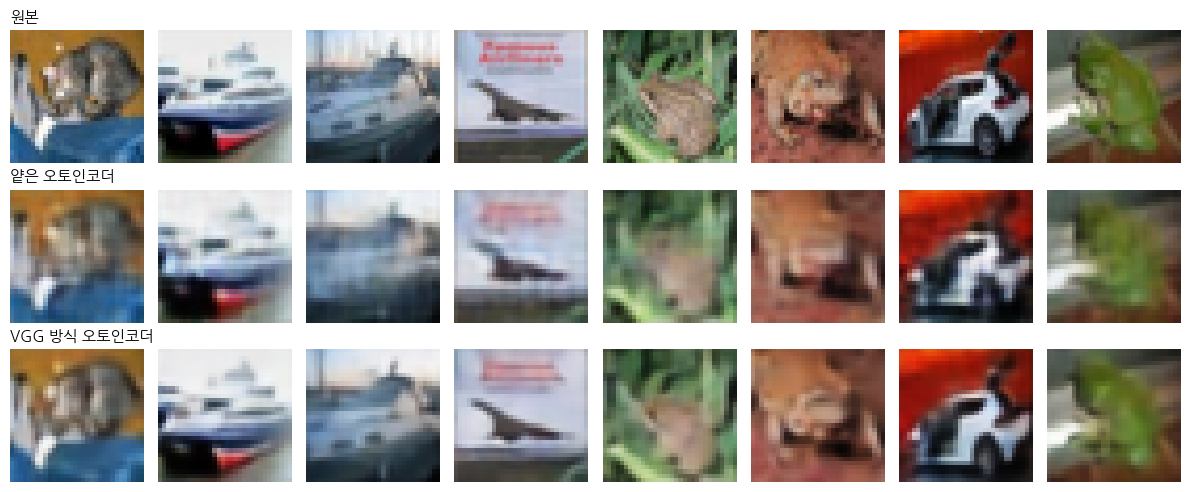

모델                            최적 에포크      평가 MSE        파라미터
------------------------------------------------------------
ShallowConvAutoEncoder            39    0.013470     139,299
VGGConvAutoEncoder                40    0.006505     443,907


In [19]:
# 복원 결과 비교
import matplotlib.pyplot as plt


@torch.no_grad()
def reconstruct(model, images):
    model.eval()
    return model(images.to(device)).cpu()


def to_image(tensor):
    # 정규화([-1, 1])를 되돌려 [0, 1] 범위로 만든다
    return tensor.permute(1, 2, 0).clamp(-1, 1).mul(0.5).add(0.5).numpy()


sample_images = torch.stack([test_set[i][0] for i in range(8)])
recon_shallow = reconstruct(ae_shallow, sample_images)
recon_vgg = reconstruct(ae_vgg, sample_images)

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
titles = ['원본', '얕은 오토인코더', 'VGG 방식 오토인코더']
for row, (images, title) in enumerate(
        zip([sample_images, recon_shallow, recon_vgg], titles)):
    for col in range(8):
        axes[row, col].imshow(to_image(images[col]))
        axes[row, col].axis('off')
    axes[row, 0].set_title(title, loc='left', fontsize=11)
fig.tight_layout()
plt.show()

print(f"{'모델':<26}{'최적 에포크':>10}{'평가 MSE':>12}{'파라미터':>12}")
print('-' * 60)
for key in ('shallow', 'vgg'):
    r = ae_results[key]
    print(f"{r['name']:<26}{r['best_epoch']:>10}{r['test_mse']:>12.6f}{r['params']:>12,}")

### 풀이 해설 — 연습 문제 8-3

구현에서 짚어야 할 것은 세 가지다.

1. **데이터 변경** — MNIST의 `(1, 28, 28)`에서 CIFAR-10의 `(3, 32, 32)`로 바뀌므로, 인코더의 첫
   입력 채널과 디코더의 마지막 출력 채널이 모두 3이 된다. 또한 CIFAR-10 데이터를 평균 0.5,
   표준편차 0.5로 정규화하면 값의 범위가 `[-1, 1]`이므로 디코더의 마지막 활성화 함수는
   `Sigmoid`가 아니라 `Tanh`여야 한다. 7장의 MNIST 오토인코더를 그대로 옮겨 오면 여기서 막힌다.
2. **VGGNet 아이디어 이식** — 단계마다 합성곱 계층을 하나에서 둘 이상으로 늘리고 필터를 3x3으로
   통일한다. 디코더에서는 전치 합성곱으로 크기를 두 배 늘린 뒤 3x3 합성곱으로 다듬는 방식이
   VGGNet의 "확대는 따로, 특징 조합은 3x3 합성곱이" 역할 분담과 맞아떨어진다.
3. **증강 미적용** — 복원 품질을 견주는 것이 목적이므로 훈련 데이터에도 증강 변환을 적용하지
   않았다. 증강을 적용하면 모델이 복원해야 할 대상 자체가 흔들려 두 모델의 비교가 흐려진다.

복원 결과와 평가 MSE는 위 실행 결과로 확인한다.